# UdaciSense: Optimized Object Recognition

## Notebook 4: Mobile Deployment

In this notebook, you'll prepare your optimized model for mobile deployment.
You'll explore how to convert your best optimized model to a cross-platform mobile-friendly format,
and evaluate the performance that UdaciSense mobile users can expect.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import necessary libraries
import copy
import os
import json
import time
import numpy as np
import pandas as pd
import pprint
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.quantization
from typing import Dict, Any, List, Tuple, Optional, Union, Callable
import warnings
import sys
sys.path.append('..')
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import (
    plot_model_comparison, plot_multiple_models_comparison, 
    create_model_summary_dashboard
)
from utils.compression import is_quantized
from utils.evaluation import evaluate_model_metrics, compare_models

In [3]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

### Step 1: Set up the Environment

In [4]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA GeForce RTX 3070 Laptop GPU)']


In [5]:
# Setup directories
os.makedirs("../models/mobile", exist_ok=True)
os.makedirs("../results/mobile", exist_ok=True)

In [6]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


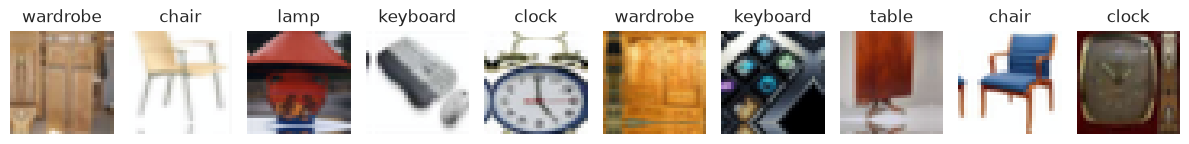


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


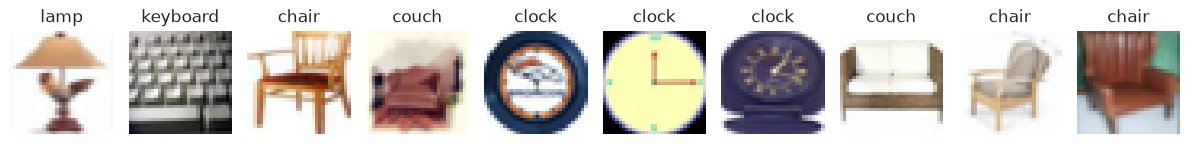

In [7]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3. Load the optimized model and metrics

In [8]:
# Choose the experiment to load for
experiment_name = "prune_quantize_graphopt_cpu"
optimized_model_path = f"../models/pipeline/{experiment_name}/model.pt"

In [9]:
# Load the optimized model
optimized_model = load_model(optimized_model_path)
print_model_summary(optimized_model)

# Load optimized model metrics
with open(f"../results/pipeline/{experiment_name}/pipeline_metrics.json", "r") as f:
    optimized_metrics = json.load(f)

print("\nOptimized Model Metrics:")
pprint.pp(optimized_metrics)

Model Architecture:
RecursiveScriptModule(original_name=MobileNetV3_Household)

Total Parameters: 0

Optimized Model Metrics:
{'pipeline_name': 'prune_quantize_graphopt_cpu',
 'steps': [{'step_name': 'post_training_pruning',
            'args': {'pruning_method': 'global_unstructured', 'amount': '0.4'},
            'metrics': {'accuracy': {'top1_acc': 86.4, 'top5_acc': 99.2},
                        'per_class_accuracy': {'clock': 95.0,
                                               'keyboard': 89.0,
                                               'lamp': 89.0,
                                               'telephone': 80.0,
                                               'television': 93.0,
                                               'bed': 85.0,
                                               'chair': 87.0,
                                               'couch': 68.0,
                                               'table': 80.0,
                                               'wardro

### Step 4. Convert optimized model for mobile

In [10]:
# Implement torch optimizations for deployment to mobile
import copy
from torch.utils.mobile_optimizer import optimize_for_mobile

def convert_model_for_mobile(
    model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 32, 32)
) -> Union[torch.jit.ScriptModule, str]:
    """
    Convert a PyTorch model to a mobile-friendly format.
    Currently focused on TorchScript but designed to be extensible.
    
    Args:
        model: PyTorch model to convert
        input_size: Shape of input tensor (possibly useful to create a dummy input)
    Returns:
        Converted model object
    """
    # Work on a copy so the caller's original model is left untouched.
    model = copy.deepcopy(model)
    model.eval()

    dummy_input = torch.randn(input_size)

    # Convert to TorchScript. Tracing is preferred (simpler, handles most
    # CNN forward passes cleanly); fall back to scripting if the model has
    # data-dependent control flow that tracing can't capture correctly.
    with torch.no_grad():
        try:
            scripted_model = torch.jit.trace(model, dummy_input, check_trace=False)
        except Exception as e:
            print(f"torch.jit.trace failed ({e}); falling back to torch.jit.script...")
            scripted_model = torch.jit.script(model)

    scripted_model.eval()

    # Freeze the module (inline parameters/buffers as constants) so the
    # mobile-optimization pass below can fold/fuse more aggressively than
    # it could on a "live" module.
    scripted_model = torch.jit.freeze(scripted_model)

    # Apply mobile-specific optimizations: fuses Conv+BN and Conv+ReLU
    # patterns, removes dropout, prepacks weights for mobile-friendly ops,
    # and strips debug info to shrink the exported artifact.
    mobile_model = optimize_for_mobile(scripted_model)

    return mobile_model

In [11]:
# Convert the model for mobile deployment
print("\nConverting model for mobile deployment...")

# Convert the model
mobile_model = convert_model_for_mobile(
    optimized_model, 
    input_size=input_size,
)

# Save the mobile model
# EXTRA: Test saving with lite interpreter instead - do you notice differences in performance?
mobile_model_path = f"../models/mobile/optimized_model_mobile.pt"
torch.jit.save(mobile_model, mobile_model_path)
print(f"Saved mobile-compatible model to: {mobile_model_path}")


Converting model for mobile deployment...
Saved mobile-compatible model to: ../models/mobile/optimized_model_mobile.pt


### Step 5: Verify Mobile Model Performance

Before packaging for deployment, let's verify that your optimized model meets the requirements.

#### Model output consistency

In [12]:
def compare_model_outputs(
    model1: nn.Module,
    model2: nn.Module,
    input_tensor: torch.Tensor,
    rtol: float = 1e-3,
    atol: float = 1e-3,
) -> bool:
    """
    Compare outputs of two models to verify consistency after conversion.
    Works with both regular PyTorch models and converted mobile models.
    
    Args:
        model1: First model
        model2: Second model
        input_tensor: Input tensor to test with
        rtol: Relative tolerance for comparison
        atol: Absolute tolerance for comparison
        
    Returns:
        True if outputs are consistent, False otherwise
    """
    # Mobile-optimized (and any TorchScript/frozen) models are built and
    # tested for CPU execution, so run both models on CPU -- this keeps
    # the comparison apples-to-apples regardless of which device either
    # model happened to be on beforehand.
    device = torch.device('cpu')

    model1 = model1.to(device)
    model2 = model2.to(device)
    model1.eval()
    model2.eval()

    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        output1 = model1(input_tensor)
        output2 = model2(input_tensor)

    # Some models return a tuple of outputs (e.g. auxiliary heads) --
    # compare just the primary output in that case.
    if isinstance(output1, tuple):
        output1 = output1[0]
    if isinstance(output2, tuple):
        output2 = output2[0]

    is_close = torch.allclose(output1, output2, rtol=rtol, atol=atol)

    if is_close:
        print("Outputs match within tolerance.")
    else:
        max_diff = torch.max(torch.abs(output1 - output2)).item()
        mean_diff = torch.mean(torch.abs(output1 - output2)).item()
        print(f"Outputs differ numerically. Max diff: {max_diff:.6f}, Mean diff: {mean_diff:.6f}")

        # Mobile optimization (fusion, packing) can introduce small
        # numerical drift even when the model is functionally equivalent --
        # what actually matters in practice is whether predictions changed,
        # so check that too rather than treating any numeric drift as a
        # hard failure.
        pred1 = output1.argmax(dim=1)
        pred2 = output2.argmax(dim=1)
        pred_match = torch.equal(pred1, pred2)
        print(f"Predicted classes match: {pred_match} (model1: {pred1.tolist()}, model2: {pred2.tolist()})")

    return is_close


# Verify model output consistency
dummy_input = torch.randn(input_size)
output_consistency = compare_model_outputs(optimized_model, mobile_model, dummy_input)
print(f"Output consistency check: {'PASSED' if output_consistency else 'FAILED'}")

Outputs match within tolerance.
Output consistency check: PASSED


#### Model size

In [13]:
# Get the model size
# Consider if you want to return both or either model size in MB vs parameter count
def get_model_size(model_path: str) -> float:
    """
    Get the size of a model, whether it is optimized or not for mobile.
    
    Args:
        model_path: Filepath to the saved model
        
    Returns:
        Float number representing model size
    """
    size_bytes = os.path.getsize(model_path)
    return size_bytes / (1024 * 1024)  # Convert to MB

optimized_size = get_model_size(optimized_model_path)
mobile_size = get_model_size(mobile_model_path)

print(f"Original model size: {optimized_size:.2f} MB")
print(f"Mobile model size: {mobile_size:.2f} MB")
print(f"\nSize change from optimized to mobile: {(mobile_size - optimized_size) / optimized_size * 100:.2f}%")

Original model size: 4.13 MB
Mobile model size: 0.59 MB

Size change from optimized to mobile: -85.63%


#### Evaluate models on test set

In [14]:
# Evaluate original optimized vs mobile model when it comes to accuracy and other performance metrics
# Feel free to choose one or more of the built-in evaluation and visualization methods, or create new ones!

def compare_models_cpu_safe(baseline_model, optimized_model, dataloader, num_classes, class_names, input_size):
    """
    Thin wrapper around compare_models() that forces CPU-only inference
    timing. compare_models() -> evaluate_model_metrics() ->
    measure_inference_time() unconditionally benchmarks on CUDA whenever
    it's available -- but mobile-optimized (and any quantized) models are
    CPU-only, and running them on CUDA is a known way to hard-crash the
    process natively. We temporarily disable torch.cuda.is_available()
    for the duration of this call so that branch is never taken.
    """
    original_is_available = torch.cuda.is_available
    torch.cuda.is_available = lambda: False
    try:
        return compare_models(
            baseline_model=baseline_model,
            optimized_model=optimized_model,
            dataloader=dataloader,
            device=torch.device('cpu'),
            num_classes=num_classes,
            class_names=class_names,
            input_size=input_size,
        )
    finally:
        torch.cuda.is_available = original_is_available


# Compare optimized (pre-mobile) vs. mobile-optimized model
comparison = compare_models_cpu_safe(
    optimized_model, mobile_model, test_loader,
    num_classes=len(class_names), class_names=class_names, input_size=input_size,
)

print(f"Optimized model accuracy: {comparison['baseline']['accuracy']['top1_acc']:.2f}%")
print(f"Mobile model accuracy:    {comparison['optimized']['accuracy']['top1_acc']:.2f}%")
print(f"Size: {comparison['baseline']['size']['model_size_mb']:.2f} MB -> "
      f"{comparison['optimized']['size']['model_size_mb']:.2f} MB "
      f"({comparison['improvements']['size_reduction']:.1%} reduction)")

if comparison['improvements']['inference'].get('cpu'):
    print(f"CPU inference: {comparison['baseline']['timing']['cpu']['avg_time_ms']:.2f} ms -> "
          f"{comparison['optimized']['timing']['cpu']['avg_time_ms']:.2f} ms "
          f"({comparison['improvements']['inference']['cpu']['speedup']:.1f}x speedup)")

print(f"Accuracy change: {comparison['improvements']['accuracy_change']*100:+.2f} points")

Get metrics of baseline model...


cpu runs: 100%|██████████| 100/100 [00:00<00:00, 163.19it/s]


Get metrics of optimized model...


cpu runs: 100%|██████████| 100/100 [00:00<00:00, 146.37it/s]


Optimized model accuracy: 86.40%
Mobile model accuracy:    86.40%
Size: 0.59 MB -> 0.59 MB (0.0% reduction)
CPU inference: 6.14 ms -> 6.85 ms (0.9x speedup)
Accuracy change: +0.00 points


#### Benchmark Mobile Performance

In this section, you should develop a strategy for benchmarking the model on actual mobile 
hardware. Since we can't easily test on ARM mobile devices in this environment, describe:

1. What tools and frameworks you would use for mobile benchmarking?
2. What specific metrics you would collect?
3. How you would set up a fair comparison between models?
4. What mobile-specific factors you would control for in your tests?

Write your benchmarking approach in the final report directly.

--------

**TODO: Collect results on mobile conversion and considerations for model deployment**

After converting your optimized model for mobile deployment, analyze how the model will perform in real-world mobile environments.

Consider these guiding questions:
- How did the mobile conversion affect the model's performance characteristics?
- What mobile-specific considerations impact this model's deployment?
- How would you rigorously benchmark performance across different devices?
- What challenges might arise in production deployment scenarios?
- What future improvements would you prioritize for model deployment?

Provide an analysis that demonstrates your understanding of mobile deployment considerations for the UdaciSense computer vision model.

## Optimized Model Mobile Deployment Analysis for UdaciSense Computer Vision Model

*Replace this with your analysis*

> 🚀 **Next Step:** 
> Collect all your results and insights in `report.md`! 